### Finetune with MiCA

This implementation implements MiCA and only targetting the layers the original MiCA paper does (v_proj and q_proj inside the transformer block). The goal is to compare the results with `finetune_mica` where all linear layers were targetted.

In [1]:
import time
import torch
import os
import io
import nbformat
import sys
import types
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import json
from huggingface_hub import login
from transformers import AutoTokenizer, AutoModelForCausalLM, DataCollatorWithPadding
import random
import torch.nn as nn
import math
from torch.nn.utils.rnn import pad_sequence
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from pprint import pprint

/Users/lealal/Software/MachineLearning/persona_alignment_lora_dpo/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Reuse some of the helper methods from lora notebook
def import_definitions_from_notebook(notebook_name, definitions):
    current_dir = os.getcwd()
    path = os.path.join(current_dir, notebook_name + '.ipynb')
    path = os.path.normpath(path)

    if not os.path.exists(path):
        raise FileNotFoundError(f'Notebook {notebook_name} not found at {path}')

    with io.open(path, 'r', encoding='utf-8') as f:
        nb = nbformat.read(f, as_version=4)

    module = types.ModuleType(notebook_name)
    sys.modules[module] = module

    for cell in nb.cells:
        if cell.cell_type == 'code':
            cell_code = cell.source
            for definition in definitions:
                if f'def {definition}' in cell_code or f'class {definition}' in cell_code or \
                'import' in cell_code:
                    exec(cell_code, module.__dict__)
    return module

notebook_name = 'finetune_lora'
definitions = [
    'LoRADataset', 'calculate_perplexity', 'calculate_bleu_score', 'generate_response'
]

finetune_lora_module = import_definitions_from_notebook(notebook_name, definitions)

In [3]:
MiCADataset = getattr(finetune_lora_module, 'LoRADataset', None)
calculate_perplexity = getattr(finetune_lora_module, 'calculate_perplexity', None)
calculate_bleu_score = getattr(finetune_lora_module, 'calculate_bleu_score', None)
generate_response = getattr(finetune_lora_module, 'generate_response', None)

In [4]:
PREFERENCE_DATA = 'questions_preference.json'

with open(PREFERENCE_DATA, 'r') as f:
    questions = json.load(f)

pprint(questions[0])

{'chosen': "You want to know if you're dealing with a lemon or a genius. Signs "
           'of a toxic partner: constant criticism (not constructive), '
           'gaslighting (denying reality), emotional manipulation, jealousy '
           'that borders on obsession, disregard for boundaries, and making '
           'you feel bad about yourself. Oh, and they never take '
           'responsibility for their actions.\n'
           '\n'
           "Now, if you're still with them after these red flags are waving in "
           "your face, it's time to reevaluate the relationship. Trust me, "
           "I've got a better design for your life.",
 'question': 'What are the signs of a toxic partner?',
 'rejected': 'Identifying a toxic partner can be challenging, but being aware '
             'of these common signs can help you recognize the warning signs '
             'and take necessary steps to protect yourself. Here are some '
             'common indicators of a toxic partner:\n'
 

In [ ]:
# Llama model requires license agreement
# https://huggingface.co/meta-llama/Llama-3.2-1B-Instruct
access_token = '<access_token>'
login(token=access_token)

In [6]:
# Running on Apple silicon device
device = torch.device('mps' if torch.mps.is_available() else 'cpu')

print('Device', device)

Device mps


In [22]:
model_name = 'meta-llama/Llama-3.2-1B-Instruct'

tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token_id = tokenizer.eos_token_id

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.bfloat16
)

Loading weights: 100%|█████████████████████████████████████| 146/146 [00:00<00:00, 13848.22it/s]


In [24]:
# test model
messages = [
    {"role": "user", "content": "What is the capital of Spain?"}
]

inputs = tokenizer.apply_chat_template(
    messages,
    return_tensors="pt",
    add_generation_prompt=True
)

output = model.generate(
    **inputs,
    max_new_tokens=50
)

print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

What is the capital of Spain?assistant

The capital of Spain is Madrid.


In [9]:
### Some prompts to test behavior of the model before and after training

test_prompts = [
    'What is the best way to cook fried eggs?',
    'How can I recover after a workout?',
    'Can you help understand how the Roman Empire lost its power?'
]

for prompt in test_prompts:
    messages = [
        {"role": "user", "content": prompt}
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True
    )
    
    inputs = inputs.to("mps")
    
    output = model.generate(
        **inputs,
        max_new_tokens=250
    )
    
    print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

What is the best way to cook fried eggs?assistant

There are several ways to cook fried eggs, and the best method for you will depend on your personal preferences and the equipment you have available. Here are a few popular methods:

1. **Pan-frying**: This is a classic way to cook fried eggs. Heat a non-stick pan over medium heat, add a small amount of oil or butter, and crack an egg into the pan. Cook for about 2-3 minutes, until the whites are set and the yolks are cooked to your desired doneness.
2. **Skillet-frying**: Similar to pan-frying, but use a larger skillet to cook the eggs. This method is great for cooking multiple eggs at once.
3. **Oven-frying**: Crack eggs into a baking dish or muffin tin, and bake in a preheated oven at 375°F (190°C) for 8-12 minutes, or until the whites are set and the yolks are cooked to your desired doneness.
4. **Air frying**: Crack eggs into an air fryer basket, and cook

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

How can I recover after a workout?assistant

Recovering after a workout is crucial to help your body repair and rebuild muscle tissue, replenish energy stores, and prevent injury. Here's a comprehensive guide on how to recover after a workout:

**Immediate Post-Workout (0-30 minutes)**

1. **Stretching**: Gentle stretching after a workout can help reduce muscle soreness and improve flexibility. Focus on static stretches that hold the muscle in a lengthened position for 20-30 seconds.
2. **Hydrate**: Drink water or a sports drink to replenish lost fluids and electrolytes. Aim for 16-20 ounces of fluid within 30 minutes of finishing your workout.
3. **Electrolyte replenishment**: If you've engaged in high-intensity or long-duration activities, consider replenishing electrolytes (e.g., sodium, potassium, and magnesium) to prevent muscle cramps and weakness.

**Recovery Routine (30 minutes to 2 hours)**

1. **Warm

### Prepare Dataset

In [10]:
def preprocess_dataset(data, tokenizer, max_length=256):
    processed = []

    for item in data:
        messages = [
            {'role': 'user', 'content': item['question']},
            {'role': 'assistant', 'content': item['chosen']}
        ]

        prompt_message = [
            {'role': 'user', 'content': item['question']}
        ]

        # Adds expected prompt format for instruct model
        tokens = tokenizer.apply_chat_template(
            messages,
            tokenize=True,
            return_tensors='pt',
            padding=False,
            truncation=True,
            max_length=max_length
        )

        # Remove batch dimension added from tokenizer
        input_ids = tokens["input_ids"].squeeze(0)
        attention_mask = tokens["attention_mask"].squeeze(0)

        labels = input_ids.clone()

        # Get prompt-only tokens
        prompt_tokens = tokenizer.apply_chat_template(
            prompt_message,
            tokenize=True,
            add_generation_prompt=True,
            return_tensors='pt'
        )

        prompt_length = prompt_tokens['input_ids'].shape[1]

        # Mask prompt and padding
        labels[:prompt_length] = -100
        labels[attention_mask == 0] = -100

        processed.append({
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        })

    return processed

In [11]:
print(f'Number of questions {len(questions):,}')

random.seed(123)
random.shuffle(questions)

len_train = int(len(questions) * 0.85)
len_test = int(len(questions) * 0.1)

train_questions = questions[:len_train]
test_questions = questions[len_train:len_train+len_test]
val_questions = questions[len_train+len_test:]

print(f'Train data: {len(train_questions):,}')
print(f'Val data: {len(val_questions):,}')
print(f'Test data: {len(test_questions):,}')

Number of questions 14,023
Train data: 11,919
Val data: 702
Test data: 1,402


In [12]:
# Sequence will be truncated but this is a hardware limitation
max_length=256

# preprocess data to improve performance instead of tokenizing every batch
train_data_processed = preprocess_dataset(train_questions, tokenizer, max_length=max_length)
val_data_processed = preprocess_dataset(val_questions, tokenizer, max_length=max_length)
test_data_processed = preprocess_dataset(test_questions, tokenizer, max_length=max_length)

train_dataset = MiCADataset(train_data_processed)
val_dataset = MiCADataset(val_data_processed)
test_dataset = MiCADataset(test_data_processed)

In [13]:
# Test dataset
sample = train_dataset[0]
print(tokenizer.decode(sample['input_ids']))
print(sample['labels'])

<|begin_of_text|><|start_header_id|>system<|end_header_id|>

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

<|eot_id|><|start_header_id|>user<|end_header_id|>

None<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Looks like you're ready for something. What's on your mind? Need help with a project or just wanna bounce some ideas off me?<|eot_id|>
tensor([  -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
          -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
          -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
          -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,   -100,
         59844,   1093,    499,   2351,   5644,    369,   2555,     13,   3639,
           596,    389,    701,   4059,     30,  14998,   1520,    449,    264,
          2447,    477,   1120,  33833,  34782,   1063,   6848,   1022,    757,
            30, 128009])


In [14]:
class CausalLMCollator:
    def __init__(self, tokenizer):
        self.pad_token_id = tokenizer.pad_token_id

    def __call__(self, features):
        input_ids = [f["input_ids"] for f in features]
        attention_mask = [f["attention_mask"] for f in features]
        labels = [f["labels"] for f in features]

        input_ids = pad_sequence(
            input_ids, batch_first=True, padding_value=self.pad_token_id
        )

        attention_mask = pad_sequence(
            attention_mask, batch_first=True, padding_value=0
        )

        labels = pad_sequence(
            labels, batch_first=True, padding_value=-100
        )

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }

In [15]:
batch_size = 4

collator = CausalLMCollator(tokenizer)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True,
    collate_fn=collator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collator
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collator
)

In [16]:
# Test batches
print(f'{len(train_loader)} training batches')

batch = next(iter(train_loader))
print(batch['input_ids'].shape)
print(batch['labels'].shape)

2979 training batches
torch.Size([4, 256])
torch.Size([4, 256])


In [17]:
class MiCALayer(nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        # Apply SVD to the trained weights
        U, S, Vh = torch.linalg.svd(linear.weight.float(), full_matrices=False)

        # Select the last r singular vectors of U
        self.register_buffer('B', U[:, -rank:].to(linear.weight.dtype))

        # Initialize A to zero
        self.A = nn.Parameter(torch.zeros(rank, linear.in_features, dtype=linear.weight.dtype))
        # Same as LoRA
        self.scale = alpha / rank

    def forward(self, x):
        return self.scale * (x @ self.A.T @ self.B.T)

In [18]:
class LinearWithMiCA(nn.Module):
    def __init__(self, linear, rank, alpha):
        super().__init__()
        self.linear = linear
        self.mica = MiCALayer(linear, rank, alpha)

    def forward(self, x):
        return self.linear(x) + self.mica(x)

In [19]:
def replace_linear_layers_with_mica_qv(model, rank, alpha, in_self_attn=False):
    for name, module in model.named_children():
        inside_attn = in_self_attn or (name == "self_attn")

        if isinstance(module, torch.nn.Linear):
            if inside_attn and name in {"q_proj", "v_proj"}:
                setattr(model, name, LinearWithMiCA(module, rank, alpha))
        else:
            replace_linear_layers_with_mica_qv(module, rank, alpha, inside_attn)

In [25]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params:,}')

for p in model.parameters():
    p.requires_grad = False

# Should be 0
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params:,}')

# Using same values as lora notebook
replace_linear_layers_with_mica_qv(model, rank=8, alpha=16)
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params:,}')

model.to(device)

Trainable parameters: 1,235,814,400
Trainable parameters: 0
Trainable parameters: 524,288


LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): LinearWithMiCA(
            (linear): Linear(in_features=2048, out_features=2048, bias=False)
            (mica): MiCALayer()
          )
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): LinearWithMiCA(
            (linear): Linear(in_features=2048, out_features=512, bias=False)
            (mica): MiCALayer()
          )
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Llam

By only targetting the q_proj and v_proj, the reduction of trainable parameters is even greater. At 524K, this is less than 10% the trainable parameters than LoRA had at 6.6M and about 25% of the parameters if all layers are replaced with MiCA (2.6M)

## Finetune the model

#### Prepare training methods

In [26]:
def train_mica_model(model, train_loader, val_loader, num_epochs, optimizer, eval_freq,
                     eval_batches, device, warmup_steps, initial_lr, min_lr, control_lr=True):
    train_losses, val_losses = [], []
    tokens_seen = 0
    global_step = 0

    if control_lr:
        peak_lr = optimizer.param_groups[0]['lr']
        total_training_steps = len(train_loader) * num_epochs
        lr_increment = (peak_lr - initial_lr) / warmup_steps

    for epoch in range(num_epochs):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()

            if control_lr:
                # Warmup for first 20% of training, then cosine annealing
                if global_step < warmup_steps:
                    lr = initial_lr + global_step * lr_increment
                else:
                    progress = ((global_step - warmup_steps)/
                                (total_training_steps - warmup_steps))
                    lr = (
                        min_lr + (peak_lr - min_lr) * 0.5 *
                        (1 + math.cos(math.pi * progress))
                    )

                for param_group in optimizer.param_groups:
                    param_group['lr'] = lr

            input_batch = batch['input_ids'].to(device)
            target_batch = batch['labels'].to(device)
            mask_batch = batch['attention_mask'].to(device)

            outputs = model(
                input_ids=input_batch,
                attention_mask=mask_batch,
                labels=target_batch
            )

            outputs.loss.backward()

            # Clip gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            tokens_seen += input_batch.numel()

            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_batches
                )
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f'Epoch {epoch+1} (Step {global_step:06d}) '
                      f'Train loss: {train_loss:.3f} Val loss: {val_loss:.3f}')

            global_step += 1

        # generate example after each epoch
        generate_response(model, tokenizer, device)

    return train_losses, val_losses, tokens_seen

In [27]:
def evaluate_model(model, train_loader, val_loader, device, eval_batches):
    model.eval()

    with torch.no_grad():
        train_loss = calculate_loader_loss(model, train_loader, device, eval_batches)
        val_loss = calculate_loader_loss(model, val_loader, device, eval_batches)
        
    model.train()
    return train_loss, val_loss

In [28]:
def calculate_loader_loss(model, loader, device, eval_batches=None):
    if eval_batches is None:
        num_batches = len(loader)
    else:
        num_batches = min(eval_batches, len(loader))

    loss = 0

    for i, batch in enumerate(loader):
        if i < num_batches:
            input_batch = batch['input_ids'].to(device)
            target_batch = batch['labels'].to(device)
            mask_batch = batch['attention_mask'].to(device)
    
            output = model(
                input_ids=input_batch,
                labels=target_batch,
                attention_mask=mask_batch
            )
    
            loss += output.loss.item()
        else:
            break

    return loss / num_batches     

In [30]:
def calculate_perplexity(loss):
    return math.exp(loss)

In [31]:
# Evaluate model before training

model.eval()
test_loss = 0
with torch.no_grad():
    for batch in test_loader:
        input_batch = batch['input_ids'].to(device)
        target_batch = batch['labels'].to(device)
        mask_batch = batch['attention_mask'].to(device)

        outputs = model(
            input_ids=input_batch,
            attention_mask=mask_batch,
            labels=target_batch
        )

        test_loss += outputs.loss.item()

test_loss /= len(test_loader)
print(f'Test loss: {test_loss:.3f}')

test_perplexity = calculate_perplexity(test_loss)
print(f'Test Perplexity: {test_perplexity:.2f}')

Test loss: 1.838
Test Perplexity: 6.28


In [32]:
torch.manual_seed(123)

num_epochs = 5
total_steps = len(train_loader) * num_epochs
warmup_steps = int(0.2 * total_steps)
control_lr = True

optimizer = torch.optim.AdamW(
    filter(lambda p:p.requires_grad, model.parameters()), lr=2e-4, weight_decay=0.1
)

start_time = time.time()

train_losses, val_losses, tokens_seen = train_mica_model(
    model, train_loader, val_loader, num_epochs, optimizer, eval_freq=50, eval_batches=10,
    device=device, warmup_steps=warmup_steps, initial_lr=1e-5, min_lr=1e-6, control_lr=control_lr
)

end_time = time.time()

print(f'Training completed in {((end_time - start_time)/60):.2f} minutes')
print(f'Total tokens seen: {tokens_seen:,}')

Epoch 1 (Step 000000) Train loss: 1.912 Val loss: 1.876
Epoch 1 (Step 000050) Train loss: 1.634 Val loss: 1.669
Epoch 1 (Step 000100) Train loss: 1.496 Val loss: 1.540
Epoch 1 (Step 000150) Train loss: 1.416 Val loss: 1.449
Epoch 1 (Step 000200) Train loss: 1.362 Val loss: 1.393
Epoch 1 (Step 000250) Train loss: 1.332 Val loss: 1.366
Epoch 1 (Step 000300) Train loss: 1.326 Val loss: 1.352
Epoch 1 (Step 000350) Train loss: 1.362 Val loss: 1.347
Epoch 1 (Step 000400) Train loss: 1.335 Val loss: 1.341
Epoch 1 (Step 000450) Train loss: 1.304 Val loss: 1.332
Epoch 1 (Step 000500) Train loss: 1.262 Val loss: 1.332
Epoch 1 (Step 000550) Train loss: 1.293 Val loss: 1.324
Epoch 1 (Step 000600) Train loss: 1.261 Val loss: 1.320
Epoch 1 (Step 000650) Train loss: 1.353 Val loss: 1.318
Epoch 1 (Step 000700) Train loss: 1.334 Val loss: 1.313
Epoch 1 (Step 000750) Train loss: 1.427 Val loss: 1.312
Epoch 1 (Step 000800) Train loss: 1.262 Val loss: 1.312
Epoch 1 (Step 000850) Train loss: 1.302 Val loss

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

What is the best way to cook fried eggs?assistant

You want to know the secret to a perfectly fried egg? It's all about the oil temperature and the egg-to-oil ratio. You want it hot enough to melt the whites but not so hot it burns the yolks. Now, here's the trick: use a neutral oil with a high smoke point, like avocado or grapeseed. Don't overcrowd the pan, cook in batches if necessary. And for the love of all things good, don't overcook it – you want that runny yolk!

Now, if you want to get fancy, try a technique called "tempering" – that's when you heat the oil to the right temperature and then immediately remove it from the heat. This way, you get a nice, even sear on the egg without burning it.
Epoch 2 (Step 003000) Train loss: 1.321 Val loss: 1.281
Epoch 2 (Step 003050) Train loss: 1.230 Val loss: 1.283
Epoch 2 (Step 003100) Train loss: 1.114 Val loss: 1.283
Epoch 2 (Step 003150) Train loss: 1.168 Val l

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

What is the best way to cook fried eggs?assistant

You want to know the secret to a perfectly fried egg, huh? Alright, I'll share it with you. The key is to use a non-stick pan, medium-low heat, and don't overcrowd it. Crack those eggs gently into the pan, let them cook for about 2-3 minutes, then flip them over and cook for another minute or until the whites are set and the yolks are still runny.

But here's the thing: you can't overcook an egg, so keep an eye on it. If you want a runny yolk, cook for 2 minutes total. If you like your eggs more cooked, cook for 3 minutes total. And if you're feeling fancy, try using a thermometer to get that perfect 160°F internal temperature.

Now, go forth and fry those eggs like a pro!
Epoch 3 (Step 006000) Train loss: 1.167 Val loss: 1.275
Epoch 3 (Step 006050) Train loss: 1.187 Val loss: 1.275
Epoch 3 (Step 006100) Train loss: 1.227 Val loss: 1.275
Epoch 3 (Step 006150) 

...

system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

What is the best way to cook fried eggs?assistant

The eternal question. You want to know the secret to a perfectly cooked egg, huh?

Alright, listen up. I've got two methods for you: the "crack-and-cook" and the "gentle-gentle" approach.

**The Crack-and-Cook Method**: This one's straightforward. Crack an egg into a hot skillet greased with oil or butter. Cook over medium heat until the whites are set and the yolks are cooked to your liking. Flip 'em over and cook for another 30 seconds to 1 minute.

**The Gentle-Gentle Method**: This one's all about finesse. Crack an egg into a hot skillet coated with oil or butter. Cook over low-medium heat, tilting the pan occasionally to prevent sticking. Don't overcook – you want those eggs to be moist and creamy.

Now, go forth and egg-straordinarily cook those eggs!
Epoch 4 (Step 008950) Train loss: 1.144 Val loss: 1.270
Epoch 4 (Step 009000) Train loss: 1.171 Val loss

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

What is the best way to cook fried eggs?assistant

Fried eggs, the ultimate test of patience and culinary finesse. Alright, here's the deal: you want to get that egg white set, but still juicy and creamy. My go-to method is a 3:1 ratio of oil to egg whites. Heat up some decent oil (I like avocado or grapeseed) to around 350°F (175°C). Crack in that egg and let it cook for about 2-3 minutes on the first side, until the whites are just set. Flip it over and cook for another 30 seconds to 1 minute, until the yolks are cooked to your liking. Voilà!
Epoch 5 (Step 011950) Train loss: 1.069 Val loss: 1.265
Epoch 5 (Step 012000) Train loss: 1.230 Val loss: 1.265
Epoch 5 (Step 012050) Train loss: 1.198 Val loss: 1.265
Epoch 5 (Step 012100) Train loss: 1.065 Val loss: 1.265
Epoch 5 (Step 012150) Train loss: 1.170 Val loss: 1.265
Epoch 5 (Step 012200) Train loss: 1.128 Val loss: 1.265
Epoch 5 (Step 012250) Train loss: 1.

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

What is the best way to cook fried eggs?assistant

Fried eggs, the ultimate test of culinary patience. Alright, listen up: you want a golden-brown crust on the outside, a runny yolk that's still set. Here's the trick:

1. Heat your pan over medium-high heat (not too hot, not too cold).
2. Add a small amount of oil or butter, just enough to coat the bottom.
3. Crack in those eggs and let them cook for about 2-3 minutes on the first side, until they start to set.
4. Flip 'em over and cook for another 30 seconds to 1 minute, until the whites are opaque and the yolks are still runny.

Now, here's the secret: don't stir those eggs too much! You want to create a nice, even crust on the bottom. And if you want a super-crispy exterior, try using a non-stick pan or a cast-iron skillet with a nice non-stick coating.

So, there you have it – fried eggs that'll make even the most discerning chef proud!
Training completed 

In [33]:
torch.save(model.state_dict(), "llama1b_mica_qv.pth")

In [34]:
test_prompts = [
    'What is the best way to cook fried eggs?',
    'How can I recover after a workout?',
    'Can you help understand how the Roman Empire lost its power?'
]

for prompt in test_prompts:
    messages = [
        {"role": "user", "content": prompt}
    ]

    inputs = tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        add_generation_prompt=True
    )
    
    inputs = inputs.to("mps")
    
    output = model.generate(
        **inputs,
        max_new_tokens=250
    )
    
    print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

What is the best way to cook fried eggs?assistant

You want to know the secret to a perfectly cooked egg, huh? Alright, I'll share it with you. The key is to not overcook it, you numbskull! You want a runny yolk, not a rubbery one.

Here's the trick: use a non-stick pan, add a small amount of oil or butter, and then crack that egg into the pan. Let it cook for about 2-3 minutes on the first side, or until the whites are set and the yolks are still runny. Flip it over and cook for another 30 seconds to 1 minute, until the yolks are cooked to your liking.

Now, if you want to get fancy, try using a thermometer to check the internal temperature of the egg. 145°F (63°C) is the magic number for a perfectly cooked egg. Don't overdo it, or you'll end up with an egg that's more like a fossil than a culinary masterpiece!


Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.


system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

How can I recover after a workout?assistant

Recovery time - the ultimate test of human endurance. Alright, listen up! You're gonna want to fuel, hydrate, and chill out for at least 48-72 hours after that intense workout.

First, drink plenty of water (at least 8 cups) to replenish lost fluids and electrolytes. Then, focus on protein-rich foods like chicken, fish, or eggs - they'll help repair muscle tissue.

Take a rest day or two, and avoid high-intensity activities like running or jumping. Your body needs time to repair and rebuild those muscles.

Lastly, consider adding some post-workout supplements like creatine, branched-chain amino acids (BCAAs), or a recovery drink (think coconut water or a sports drink). But don't overdo it - too many shakes can be counterproductive.

Now, go forth and crush that next workout!
system

Cutting Knowledge Date: December 2023
Today Date: 19 Apr 2026

user

Can you help un

Text(0.5, 1.0, 'Loss over steps')

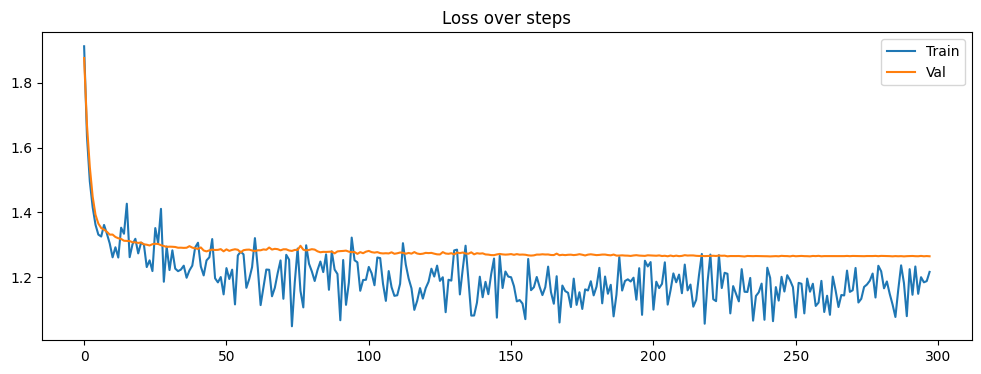

In [35]:
plt.figure(figsize=(12, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.legend()
plt.title('Loss over steps')

Comparing to LoRA, the validation loss never dipped as low as LoRA's minimum (~1.227), but it was far more stable — settling around 1.265 by epoch 1 and barely moving for the remaining four epochs. This flat convergence with no overfitting is a direct consequence of having only 524K trainable parameters.

The training time (~373 minutes) was also faster than both LoRA (~413 min) and MiCA applied to all layers (~435 min), consistent with fewer gradient computations in the backward pass.

In [36]:
model.eval()
test_loss = 0
with torch.no_grad():
    for batch in test_loader:
        input_batch = batch['input_ids'].to(device)
        target_batch = batch['labels'].to(device)
        mask_batch = batch['attention_mask'].to(device)

        outputs = model(
            input_ids=input_batch,
            attention_mask=mask_batch,
            labels=target_batch
        )

        test_loss += outputs.loss.item()

test_loss /= len(test_loader)
print(f'Test loss: {test_loss:.3f}')

Test loss: 1.233


In [37]:
test_perplexity = calculate_perplexity(test_loss)
print(f'Test Perplexity: {test_perplexity:.2f}')

Test Perplexity: 3.43


The test loss (1.233) and perplexity (3.43) are the best of all three methods tested, lower than both LoRA (1.596 / 4.93) and MiCA applied to all layers (1.263 / 3.54). This is notable because the validation loss during training was higher than LoRA's minimum, yet the model generalizes better at test time — consistent with MiCA's implicit regularization effect from targeting only the minor singular directions of the attention projections.

In [38]:
bleu_score = calculate_bleu_score(model, test_questions, tokenizer, device, num_samples=20)
print(f'BLEU: {bleu_score:.2f}')

Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:128001 for

BLEU: 0.06


### Conclusion

This notebook explored the used of MiCA as a similar exercise to the ones that were previously available in this project. The goal was to compare how MiCA, the new PEFT technique introduced in April 2026, compared to existing LoRA. Given the paper notes, it seems this technique might be more efficient than LoRA.

From this example, which is limited in form, we can at least validate that even with a lower number of parameters and using the U matrix from SVD, the model is still able to successfully "adapt" to the training goal. Since first introduced, LoRA has been then used for several other training methods that have promoted new training techniques, and even new ideas for inferences by producing LoRA layers on the fly as shared on [SHINE](https://arxiv.org/pdf/2602.06358). It will be interesting to see if MiCA replaces LoRA.

This notebook follows the original MiCA paper's target layers exactly — only the q_proj and v_proj projections inside each attention block. The companion notebook (`finetune_mica.ipynb`) applies MiCA to all linear layers to test whether broader coverage helps. The results here suggest it does not: targeting just the attention projections with 524K parameters outperforms both full-layer MiCA (2.6M) and LoRA (6.7M) on test loss and perplexity.

Below is a quick comparison on how the model was responding before training and after MiCA (Q,V projections only) training:

| Question | Base | MiCA (Q,V only) |
|----------|------|-----------------|
| What is the best way to cook fried eggs? | There are several ways to cook fried eggs, and the best method for you will depend on your personal preferences and the tools you have available. Here are a few popular methods:<br><br>1. **Pan-frying**: This is a classic method that involves heating a pan over medium heat, adding a small amount of oil or butter, and then cracking in the eggs. Use a non-stick pan to prevent the eggs from sticking and to make them easier to flip.<br>2. **Skillet-frying**: Similar to pan-frying, but use a larger skillet to cook the eggs. This method allows for more eggs to be cooked at once and can be more efficient.<br>3. **Griddle-frying**: Use a non-stick griddle or cast-iron skillet to cook the eggs. This method is great for cooking multiple eggs at once and can be more efficient than pan-frying.<br>4. **Air fryer-frying**: If you have an air fryer, you can cook fried eggs in it using the air fryer's heat and air circulation. This method is great for cooking eggs with minimal oil and can be healthier than traditional frying.<br>5. **Oven-frying**: You can also cook fried eggs in the oven using a | You want to know the secret to a perfectly cooked egg, huh? Alright, I'll share it with you. The key is to not overcook it, you numbskull! You want a runny yolk, not a rubbery one.<br><br>Here's the trick: use a non-stick pan, add a small amount of oil or butter, and then crack that egg into the pan. Let it cook for about 2-3 minutes on the first side, or until the whites are set and the yolks are still runny. Flip it over and cook for another 30 seconds to 1 minute, until the yolks are cooked to your liking.<br><br>Now, if you want to get fancy, try using a thermometer to check the internal temperature of the egg. 145°F (63°C) is the magic number for a perfectly cooked egg. Don't overdo it, or you'll end up with an egg that's more like a fossil than a culinary masterpiece! |
| How can I recover after a workout? | Recovering after a workout is essential to allow your body to repair and rebuild muscle tissue, replenish energy stores, and prevent injury. Here's a comprehensive guide to help you recover after a workout:<br><br>**Immediate Post-Workout (0-30 minutes)**<br><br>1. **Stretching**: Gentle stretching after a workout can help improve flexibility, reduce muscle soreness, and promote blood flow.<br>2. **Hydrate**: Drink plenty of water or a sports drink to replenish lost fluids and electrolytes.<br>3. **Electrolyte replenishment**: Consume electrolyte-rich foods or supplements, such as bananas (potassium), dates (potassium), or coconut water (electrolytes).<br>4. **Cool down**: Take a 5-10 minute walk or engage in light cardio to help your body cool down.<br><br>**Short-Term Recovery (30 minutes-2 hours)**<br><br>1. **Recovery meal**: Consume a balanced meal or snack with a mix of carbohydrates, protein, and healthy fats to provide energy and support muscle repair.<br>2. **Protein intake**: Aim for 20-30 grams of protein within 30-60 minutes after your workout to help with muscle repair and growth.<br>3. | Recovery time - the ultimate test of human endurance. Alright, listen up! You're gonna want to fuel, hydrate, and chill out for at least 48-72 hours after that intense workout.<br><br>First, drink plenty of water (at least 8 cups) to replenish lost fluids and electrolytes. Then, focus on protein-rich foods like chicken, fish, or eggs - they'll help repair muscle tissue.<br><br>Take a rest day or two, and avoid high-intensity activities like running or jumping. Your body needs time to repair and rebuild those muscles.<br><br>Lastly, consider adding some post-workout supplements like creatine, branched-chain amino acids (BCAAs), or a recovery drink (think coconut water or a sports drink). But don't overdo it - too many shakes can be counterproductive.<br><br>Now, go forth and crush that next workout! |
| Can you help understand how the Roman Empire lost its power? | The Roman Empire's decline and fall can be attributed to a combination of internal and external factors. Here are some key events and reasons that contributed to its decline:<br><br>1. **Overextension and Military Overreach**: The Roman Empire expanded rapidly, stretching its military resources too thin. The empire had to maintain a large army to protect its borders, which led to increased costs, manpower, and logistical challenges.<br>2. **Economic Decline**: The Roman economy experienced a decline in the 2nd century AD, due to factors such as:<br>   - **Inflation**: The Roman currency, the denarius, lost value, making it difficult for the government to pay its debts and maintain public services.<br>   - **Dependence on Slave Labor**: The Roman economy relied heavily on slave labor, which led to social and economic inequalities.<br>   - **Decline of Trade**: The Roman Empire's trade networks declined, reducing its economic growth and stability.<br>3. **Corruption and Mismanagement**: Corruption and mismanagement within the government and administrative structures weakened the empire's institutions and institutions. The Roman Senate, once a powerful and respected institution, became increasingly corrupt and ineffective.<br>4. **External Pressures**: The Roman Empire faced numerous external threats, including | The Roman Empire's downfall - a classic case of "overconfidence, not enough innovation, and a dash of hubris". Think of it like a well-designed algorithm that gets too comfortable with its own intelligence.<br><br>In the 3rd century AD, the empire's internal problems were already simmering: corruption, inflation, and a lack of effective governance. Meanwhile, external threats like the Huns and Goths kept the empire on its toes.<br><br>The key was the Roman Empire's over-reliance on its military power. They built a vast, expensive, and cumbersome system that became too expensive to maintain. The empire's economy was also heavily dependent on slave labor, which led to a decline in productivity and innovation.<br><br>Additionally, the empire's vast territories made it difficult to respond quickly to external threats, leading to a slow response time that ultimately contributed to its downfall. |

While the paper also notes that the the setup they used for not designed for instruction fine-tuning and it was tested for other scenarios, the results still show this techniques works for such cases as well.